# Reto: PCA - Breast Cancer Wisconsin

**Maestría en Ingeniería Electrónica (MaIE)**  
Universidad de Nariño  
Curso: Introducción a la Ciencia de Datos  
Instructor: Carlos Andrés Viteri Mera

---

Se aplica la metodología de Análisis de Componentes Principales (PCA) al dataset **Breast Cancer Wisconsin (Diagnostic)**.  
El dataset contiene **569 muestras** y **30 features numéricas** extraídas de imágenes de núcleos celulares.  
La variable objetivo es el diagnóstico: **M** (Maligno) o **B** (Benigno).

**Fuente:** `sklearn.datasets.load_breast_cancer()` · [UCI ML Repository](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic)

In [28]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# =====================================================================
# 1. Importar los datos y separar la variable independiente
# =====================================================================
bc = load_breast_cancer()
df = pd.DataFrame(data=bc.data, columns=bc.feature_names)
df['diagnosis'] = pd.Categorical.from_codes(bc.target, categories=['M', 'B'])

print(f"Dimensiones del dataset: {df.shape}")
print(f"Distribución del diagnóstico:\n{df['diagnosis'].value_counts()}")
df.head()

Dimensiones del dataset: (569, 31)
Distribución del diagnóstico:
diagnosis
B    357
M    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


In [29]:
features_all = list(bc.feature_names)
features_mean = [f for f in features_all if f.startswith('mean')]

X = df[features_all]
y = df['diagnosis']

# Manejo de NaN (el dataset no contiene NaN, pero se mantiene por consistencia metodológica)
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)
X = pd.DataFrame(X_imputed, columns=features_all)

# Estandarizar para que todas las variables contribuyan equitativamente
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Features totales (usadas en PCA): {len(features_all)}")
print(f"Features 'mean' (usadas en heatmap): {len(features_mean)}")

Features totales (usadas en PCA): 30
Features 'mean' (usadas en heatmap): 10


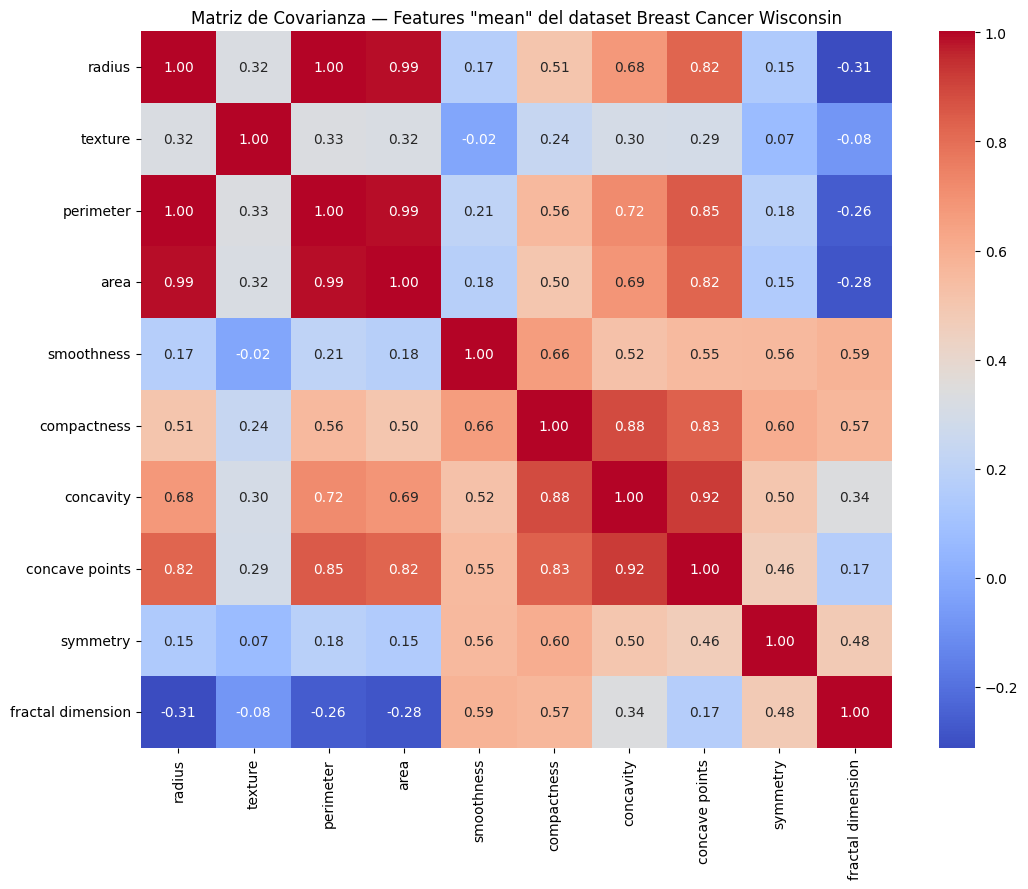

In [30]:
# =====================================================================
# 2. Calcular la matriz de covarianza y graficar mapa de calor
# =====================================================================
X_mean_scaled = StandardScaler().fit_transform(df[features_mean])
cov_matrix = np.cov(X_mean_scaled, rowvar=False)

labels_short = [f.replace('mean ', '') for f in features_mean]

plt.figure(figsize=(11, 9))
sns.heatmap(cov_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=labels_short, yticklabels=labels_short)
plt.title('Matriz de Covarianza — Features "mean" del dataset Breast Cancer Wisconsin')
plt.tight_layout()
plt.show()

### Análisis de la Matriz de Covarianza

Se observan correlaciones muy altas (> 0.9) entre **radius**, **perimeter** y **area**, lo que es esperado ya que son medidas geométricas del mismo núcleo celular. Estas redundancias son exactamente el tipo de información que PCA aprovecha para comprimir las 30 dimensiones originales en unos pocos componentes principales sin perder la mayor parte de la varianza.

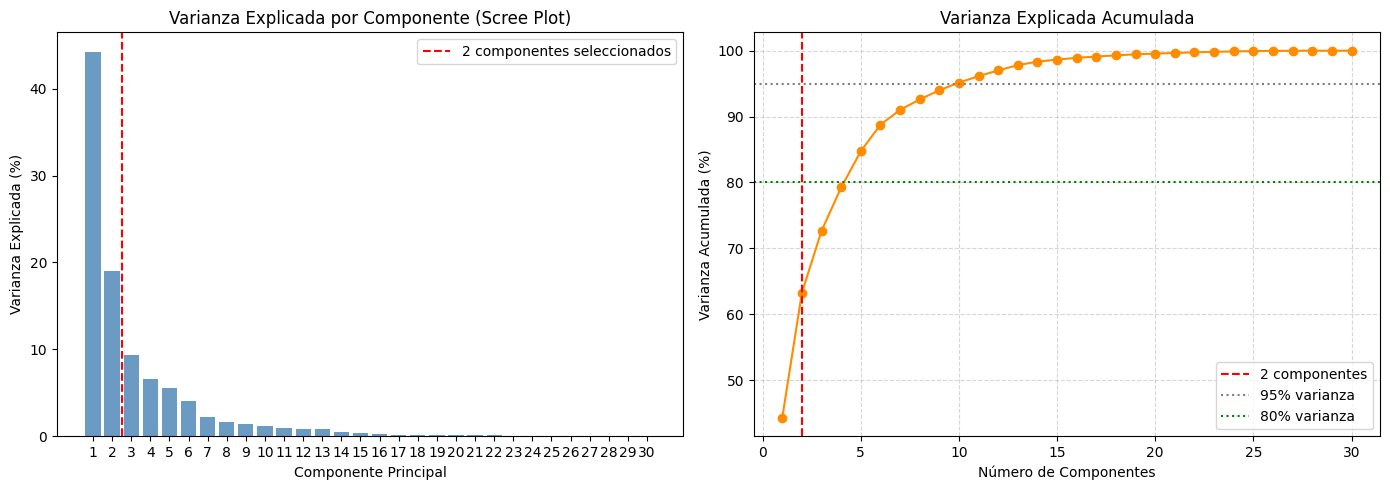

Varianza acumulada con 2 PCs: 63.24%
Varianza acumulada con 3 PCs: 72.64%
Número de PCs para alcanzar 95% de varianza: 10


In [31]:
# =====================================================================
# 3. Realizar el análisis de componentes principales (PCA)
# =====================================================================
pca = PCA()
pca.fit(X_scaled)

var_explicada = pca.explained_variance_ratio_ * 100
var_acumulada = np.cumsum(var_explicada)
eigenvalues = pca.explained_variance_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(var_explicada) + 1), var_explicada, color='steelblue', alpha=0.8)
axes[0].axvline(x=2.5, color='red', linestyle='--', label='2 componentes seleccionados')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada (%)')
axes[0].set_title('Varianza Explicada por Componente (Scree Plot)')
axes[0].set_xticks(range(1, len(var_explicada) + 1))
axes[0].legend()

axes[1].plot(range(1, len(var_acumulada) + 1), var_acumulada, marker='o', color='darkorange')
axes[1].axvline(x=2, color='red', linestyle='--', label='2 componentes')
axes[1].axhline(y=95, color='gray', linestyle=':', label='95% varianza')
axes[1].axhline(y=80, color='green', linestyle=':', label='80% varianza')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Acumulada (%)')
axes[1].set_title('Varianza Explicada Acumulada')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Varianza acumulada con 2 PCs: {var_acumulada[1]:.2f}%")
print(f"Varianza acumulada con 3 PCs: {var_acumulada[2]:.2f}%")
print(f"Número de PCs para alcanzar 95% de varianza: {np.argmax(var_acumulada >= 95) + 1}")

In [32]:
# =====================================================================
# 4. Obtener y mostrar los componentes principales (mayor varianza)
# =====================================================================
top_components = pca.components_[:2]

print(f"Varianza explicada por el Componente 1: {var_explicada[0]:.2f}%")
print(f"Varianza explicada por el Componente 2: {var_explicada[1]:.2f}%")
print(f"Varianza acumulada (2 PCs): {var_acumulada[1]:.2f}%")
print(f"Eigenvalues (primeros 2): {eigenvalues[:2].round(4)}")

for i in range(2):
    print(f"\nCargas (weights) del Componente Principal {i + 1}:")
    for feature, weight in zip(features_all, top_components[i, :]):
        print(f"  {feature:<35} {weight:+.4f}")

Varianza explicada por el Componente 1: 44.27%
Varianza explicada por el Componente 2: 18.97%
Varianza acumulada (2 PCs): 63.24%
Eigenvalues (primeros 2): [13.305   5.7014]

Cargas (weights) del Componente Principal 1:
  mean radius                         +0.2189
  mean texture                        +0.1037
  mean perimeter                      +0.2275
  mean area                           +0.2210
  mean smoothness                     +0.1426
  mean compactness                    +0.2393
  mean concavity                      +0.2584
  mean concave points                 +0.2609
  mean symmetry                       +0.1382
  mean fractal dimension              +0.0644
  radius error                        +0.2060
  texture error                       +0.0174
  perimeter error                     +0.2113
  area error                          +0.2029
  smoothness error                    +0.0145
  compactness error                   +0.1704
  concavity error                     +0.1536

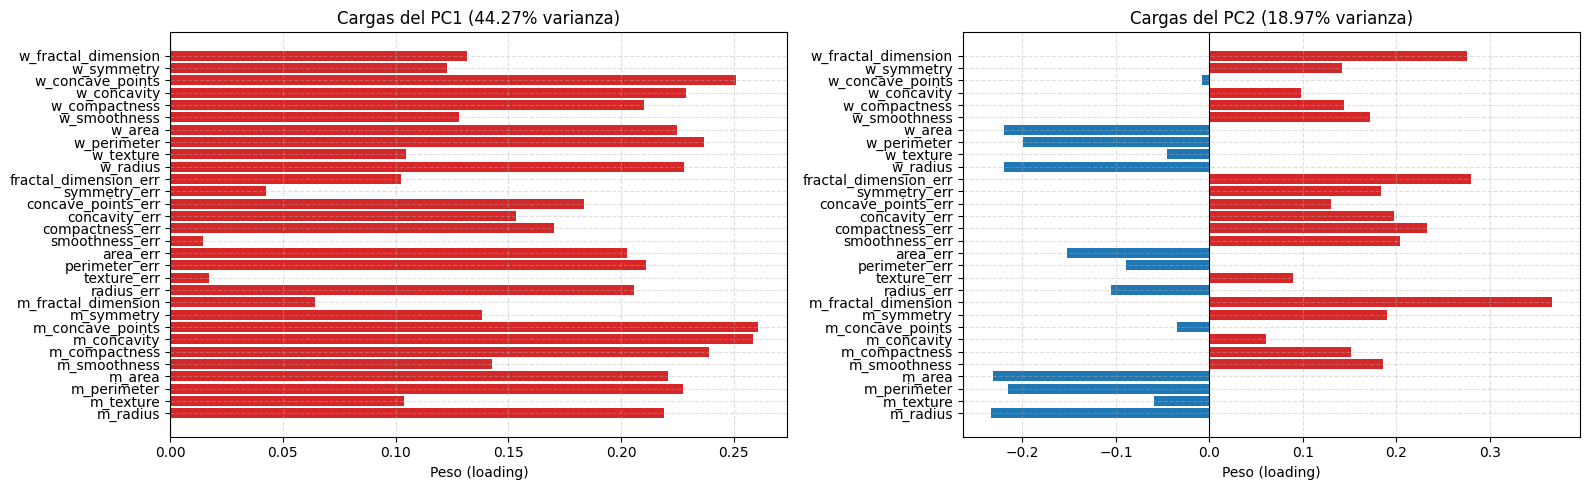

In [33]:
# Biplot de cargas: qué features dominan cada componente
labels_short_all = [f.replace('mean ', 'm_').replace('worst ', 'w_').replace(' error', '_err')
                    .replace(' ', '_') for f in features_all]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, i in zip(axes, range(2)):
    weights = top_components[i, :]
    colors = ['#d62728' if w > 0 else '#1f77b4' for w in weights]
    ax.barh(labels_short_all, weights, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Cargas del PC{i + 1} ({var_explicada[i]:.2f}% varianza)')
    ax.set_xlabel('Peso (loading)')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [34]:
# =====================================================================
# 5. Calcular las nuevas variables (Componentes) para cada fila
# =====================================================================
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=X_pca, columns=['Componente Principal 1', 'Componente Principal 2'])
df_pca['diagnosis'] = y.values

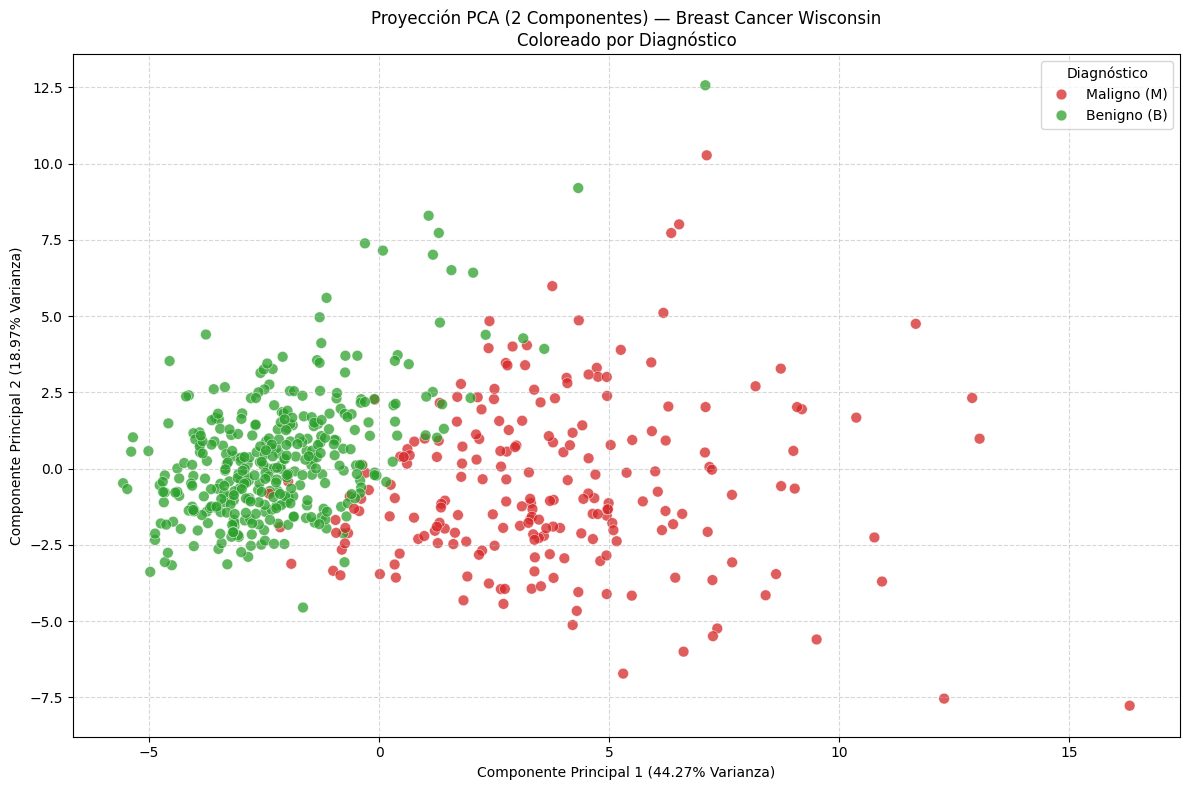

In [35]:
# =====================================================================
# 6. Realizar un gráfico tipo scatterplot coloreado por 'diagnosis'
# =====================================================================
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Componente Principal 1',
    y='Componente Principal 2',
    hue='diagnosis',
    data=df_pca,
    palette={'M': '#d62728', 'B': '#2ca02c'},
    alpha=0.75,
    edgecolor='white',
    linewidth=0.4,
    s=60
)

plt.title('Proyección PCA (2 Componentes) — Breast Cancer Wisconsin\nColoreado por Diagnóstico')
plt.xlabel(f'Componente Principal 1 ({var_explicada[0]:.2f}% Varianza)')
plt.ylabel(f'Componente Principal 2 ({var_explicada[1]:.2f}% Varianza)')
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=['Maligno (M)', 'Benigno (B)'], title='Diagnóstico')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [36]:
import plotly.express as px

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

df_pca_3d = pd.DataFrame(data=X_pca_3d,
                         columns=['Componente Principal 1', 'Componente Principal 2', 'Componente Principal 3'])
df_pca_3d['diagnosis'] = y.values

fig = px.scatter_3d(
    df_pca_3d,
    x='Componente Principal 1',
    y='Componente Principal 2',
    z='Componente Principal 3',
    color='diagnosis',
    color_discrete_map={'M': '#d62728', 'B': '#2ca02c'},
    title='Proyección PCA (3 Componentes) — Breast Cancer Wisconsin',
    labels={
        'Componente Principal 1': f'PC1 ({var_explicada[0]:.2f}%)',
        'Componente Principal 2': f'PC2 ({var_explicada[1]:.2f}%)',
        'Componente Principal 3': f'PC3 ({var_explicada[2]:.2f}%)'
    },
    opacity=0.8
)

fig.update_traces(marker=dict(size=4))
fig.update_layout(scene=dict(aspectmode='cube'))
fig.show()

## Análisis de Resultados

### Reducción de dimensionalidad
El dataset original tiene **30 features** (10 medidas por 3 estadísticos: *mean*, *error*, *worst*).  
Con solo **2 componentes principales** se retiene el **63.24% de la varianza** total; con 3 PCs se alcanza el **72.64%**, y se necesitan **10 componentes** para superar el 95%.

### Separabilidad en el espacio PCA
El scatterplot 2D muestra una **separación clara** entre tumores Malignos (M) y Benignos (B):  
- Los **Malignos** tienden a valores altos en PC1 (tamaño y forma del núcleo más irregulares).  
- Los **Benignos** se concentran en valores bajos/negativos de PC1.  
- PC2 captura principalmente la variabilidad de *error* y *dimensión fractal* entre clases.

### Interpretación del PC1
Las cargas del PC1 muestran contribuciones positivas altas de **radius, perimeter, area, concavity** y sus versiones *worst*, lo que indica que este componente refleja principalmente el **tamaño y la forma de los núcleos celulares** — el factor clínico más discriminante entre tumores benignos y malignos.

### Conclusión
PCA logra colapsar 30 dimensiones a 2 conservando suficiente información para distinguir visualmente las dos clases. Esto ilustra el poder de PCA para descubrir estructura latente en datos de alta dimensionalidad.